# WL-AKSVD Interpretability Pipeline
Load data → train → interpret → visualise.

In [1]:
import warnings
import numpy as np
import networkx as nx
from collections import Counter, defaultdict
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MaxAbsScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score

from rdkit import Chem
from rdkit.Chem import AllChem
from rdkit.Chem.Draw import rdMolDraw2D
from IPython.display import display
from PIL import Image
import io

from graph_encoders.wl import WL
from dict_learners.aksvd import AKSVD
from utils.graph_data import GraphDataLoader
from interpreter.wl_aksvd_interpreter import WLAKSVDInterpreter

warnings.filterwarnings('ignore')
print('Imports OK')

Imports OK


## 1 · Load the NCI dataset

In [2]:
data_loader = GraphDataLoader()
graphs, y, smiles = data_loader.nci_full_graphs, data_loader.nci_full_labels, data_loader.nci_full_smiles

print(f'Total graphs : {len(graphs)}')
print(f'Label dist.  : {Counter(y)}')

Loading NCI dataset


[23:20:11] Explicit valence for atom # 1 Cl, 1, is greater than permitted
[23:20:11] ERROR: Could not sanitize molecule ending on line 5976
[23:20:11] ERROR: Explicit valence for atom # 1 Cl, 1, is greater than permitted
[23:20:11] Explicit valence for atom # 0 Br, 1, is greater than permitted
[23:20:11] ERROR: Could not sanitize molecule ending on line 9488
[23:20:11] ERROR: Explicit valence for atom # 0 Br, 1, is greater than permitted
[23:20:11] Explicit valence for atom # 1 Cl, 1, is greater than permitted
[23:20:11] ERROR: Could not sanitize molecule ending on line 12926
[23:20:11] ERROR: Explicit valence for atom # 1 Cl, 1, is greater than permitted
[23:20:11] Explicit valence for atom # 1 Cl, 1, is greater than permitted
[23:20:11] ERROR: Could not sanitize molecule ending on line 13981
[23:20:11] ERROR: Explicit valence for atom # 1 Cl, 1, is greater than permitted
[23:20:12] Explicit valence for atom # 1 Cl, 1, is greater than permitted
[23:20:12] ERROR: Could not sanitize mol

Loaded 36937 graphs
Total graphs : 36937
Label dist.  : Counter({-1: 35203, 1: 1734})


Testing Smiles

In [6]:
test_smile = smiles[0]
print(y[0])
print(test_smile)

1
COc1cc2cc(c1Cl)N(C)C(=O)CC(OC(=O)C(C)C)C1(C)OC1C(C)C1CC(O)(NC(=O)O1)C(OC)C=CC=C(C)C2


## 2 · Train the pipeline

In [3]:
G_train, G_test, y_train, y_test = train_test_split(
    graphs, y, test_size=0.2, random_state=42
)
G_vocab_train, G_ML_train, y_vocab_train, y_ML_train = train_test_split(
    G_train, y_train, test_size=0.75, random_state=42
)
print(f'Vocab train : {len(G_vocab_train)}')
print(f'ML train    : {len(G_ML_train)}')
print(f'Test        : {len(G_test)}')

wl = WL()
wl_embeddings_vocab = wl.generate_training_embeddings(G_vocab_train, y_vocab_train)
print(f'\nVocab size  : {wl.n_vocab}')

aksvd = AKSVD()
aksvd.fit(training_graph_embeddings=wl_embeddings_vocab)
print(f'Dictionary  : {aksvd._dictionary.shape}')

X_ML_train = aksvd.infer(wl.generate_inferencing_embeddings(G_ML_train))
X_ML_test  = aksvd.infer(wl.generate_inferencing_embeddings(G_test))

scaler        = MaxAbsScaler()
X_ML_train_sc = scaler.fit_transform(X_ML_train)
X_ML_test_sc  = scaler.transform(X_ML_test)
print('Scaling done')

Vocab train : 7387
ML train    : 22162
Test        : 7388
Selected 6690 features via adaptive selection

Vocab size  : 6690
Dictionary  : (1024, 6690)
Scaling done


## 3 · Fit classifier

In [7]:
classifier = LogisticRegression(
    max_iter=1000, solver='saga', random_state=42, class_weight='balanced'
)
classifier.fit(X_ML_train_sc, y_ML_train)

y_pred = classifier.predict(X_ML_test_sc)
print(classification_report(y_test, y_pred))
print(f'Test accuracy: {accuracy_score(y_test, y_pred):.4f}')

              precision    recall  f1-score   support

          -1       0.98      0.85      0.91      7027
           1       0.19      0.67      0.30       361

    accuracy                           0.84      7388
   macro avg       0.59      0.76      0.60      7388
weighted avg       0.94      0.84      0.88      7388

Test accuracy: 0.8439


## 4 · Build interpreter

In [8]:
LABEL_MAP = {-1: 'Inactive', 1: 'Active',
              0: 'Inactive'}   # adjust if your labels differ

interpreter = WLAKSVDInterpreter(
    wl=wl,
    aksvd=aksvd,
    classifier=classifier,
    scaler=scaler,
    training_graphs=G_ML_train,
    training_labels=list(y_ML_train),
    training_sparse_codes=X_ML_train,
    label_map=LABEL_MAP,
)
print('Interpreter ready')

Interpreter ready


## 5 · SMILES → NetworkX graph converter

The converter auto-detects which node attribute format the training data uses,
then tries **both** candidate encodings (element symbol vs atomic number) and
keeps whichever gives the most vocabulary matches.  The final `✅ / ⚠️` line
confirms the result before you run any molecule.

In [10]:
# ── Step 1: Detect attribute KEY from G_ML_train (never from `graphs`,
# which may be overwritten by other cells).  G_ML_train always holds the
# exact objects that WL was trained on.
_sample_node = list(G_ML_train[0].nodes(data=True))[0][1]
_KEY = list(_sample_node.keys())[0]      # e.g. 'feature' or 'label'
_SAMPLE_VAL = list(_sample_node.values())[0]

print(f'Training node  →  key={_KEY!r}  sample_val={_SAMPLE_VAL!r}')


# ── Step 2: Define the two candidate VALUE functions ─────────────────────────
def _feat_symbol(atom):     return atom.GetSymbol()          # 'C', 'N', 'O'
def _feat_atomicnum(atom):  return str(atom.GetAtomicNum())  # '6', '7', '8'


# ── Step 3: Graph builder (parameterised) ─────────────────────────────────────
def _build_graph(smiles: str, key: str, feat_fn) -> nx.Graph:
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        raise ValueError(f'Cannot parse SMILES: {smiles!r}')
    g = nx.Graph()
    for atom in mol.GetAtoms():
        g.add_node(atom.GetIdx(), **{key: feat_fn(atom)})
    for bond in mol.GetBonds():
        g.add_edge(bond.GetBeginAtomIdx(), bond.GetEndAtomIdx())
    return g


# ── Step 4: Count vocabulary hits for a probe molecule ───────────────────────
# Phenol (Oc1ccccc1) contains both C and O so it exercises heteroatom encoding.
_PROBE   = 'Oc1ccccc1'
_vocab_s = {w for w, _ in wl.vocab}

def _hits(feat_fn):
    g   = _build_graph(_PROBE, _KEY, feat_fn)
    doc = wl.create_wl_hash([g])[0]
    return sum(1 for tok in doc.words if tok in _vocab_s)

_h_sym = _hits(_feat_symbol)
_h_num = _hits(_feat_atomicnum)

print(f'  symbol format  (C/N/O)  → {_h_sym} vocab hits on probe')
print(f'  atomic-num fmt (6/7/8)  → {_h_num} vocab hits on probe')


# ── Step 5: Choose the better encoding ────────────────────────────────────────
if _h_sym == 0 and _h_num == 0:
    # Neither attributed format works → WL is falling back to degree-based
    # features.  This can happen when karateclub's API changed between versions
    # and `attributed=True` is no longer being respected.  The node attribute
    # does not affect tokenisation, so any consistent choice is fine.
    _FEAT_FN = _feat_symbol
    print(
        '\n⚠️  Both encodings give 0 matches for the probe molecule.'
        '\n   WL is most likely running in degree-only mode (no attribute used).'
        '\n   Node attribute encoding does not affect tokenisation in this mode.'
        '\n   If active atoms remain 0 for all SMILES, consider retraining with'
        '\n   a fixed WL attribute name (see wl.py → create_wl_hash).'
    )
elif _h_sym >= _h_num:
    _FEAT_FN = _feat_symbol
    print(f'\n✅ Using element SYMBOL encoding  ({_h_sym} hits ≥ {_h_num})')
else:
    _FEAT_FN = _feat_atomicnum
    print(f'\n✅ Using ATOMIC NUMBER encoding  ({_h_num} hits > {_h_sym})')


# ── Step 6: Expose clean public API ──────────────────────────────────────────
def smiles_to_graph(smiles: str) -> nx.Graph:
    """Convert SMILES to a NetworkX graph matching the WL training format."""
    return _build_graph(smiles, _KEY, _FEAT_FN)


def smiles_to_mol_and_graph(smiles: str):
    """Return (RDKit Mol, NetworkX graph) for a SMILES string."""
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        raise ValueError(f'Cannot parse SMILES: {smiles!r}')
    return mol, smiles_to_graph(smiles)

Training node  →  key='feature'  sample_val='Cl'
  symbol format  (C/N/O)  → 14 vocab hits on probe
  atomic-num fmt (6/7/8)  → 0 vocab hits on probe

✅ Using element SYMBOL encoding  (14 hits ≥ 0)


## 5b · Diagnose active-atom count for any SMILES

Run this cell if a molecule shows 0 active atoms to distinguish a
*format mismatch* from a *genuine out-of-distribution molecule*.

In [11]:
def diagnose_smiles(smiles: str, top_n_tokens: int = 5):
    """
    Show WL token statistics for a SMILES molecule.
    Helps distinguish format mismatch from vocabulary gap.
    """
    g   = smiles_to_graph(smiles)
    doc = wl.create_wl_hash([g])[0]

    all_tokens = doc.words
    vocab_set  = {w for w, _ in wl.vocab}
    matches    = [t for t in all_tokens if t in vocab_set]

    sep = '─' * 55
    print(sep)
    print(f'  SMILES         : {smiles}')
    print(f'  Nodes / Edges  : {g.number_of_nodes()} / {g.number_of_edges()}')
    print(f'  Node attrs     : {dict(list(g.nodes(data=True))[:2])}')
    print(sep)
    print(f'  Vocab size           : {len(vocab_set)}')
    print(f'  WL tokens generated  : {len(all_tokens)}')
    print(f'  Vocabulary matches   : {len(matches)}')
    print()

    if len(matches) == 0:
        print('  ❌ Zero matches — likely causes:')
        print('     1. Node attribute format mismatch (key or value encoding wrong)')
        print('     2. All matching tokens pruned during discriminative vocab selection')
        print('        (molecule has only non-discriminative patterns)')
        print()
        print('  Sample WL tokens from THIS molecule:')
        for t in all_tokens[:top_n_tokens]:
            print(f'    {t}')
        print('  Sample tokens from the VOCABULARY:')
        for t in list(vocab_set)[:top_n_tokens]:
            print(f'    {t}')
        print()
        print('  If the two sets look structurally different (different hash lengths or')
        print('  prefixes), the attribute encoding is wrong.  If they look similar in')
        print('  format but are different values, the patterns simply are not discriminative.')
    else:
        pct = 100 * len(matches) / max(len(all_tokens), 1)
        print(f'  ✅ {len(matches)} matched tokens ({pct:.1f}% coverage)')
        print(f'  Sample matched tokens: {matches[:top_n_tokens]}')

    print(sep)


# Example — run for any molecule that shows 0 active atoms:
diagnose_smiles('COc1cc2cc(c1Cl)N(C)C(=O)CC(OC(=O)C(C)C)C1(C)OC1C(C)C1CC(O)(NC(=O)O1)C(OC)C=CC=C(C)C2')  

───────────────────────────────────────────────────────
  SMILES         : COc1cc2cc(c1Cl)N(C)C(=O)CC(OC(=O)C(C)C)C1(C)OC1C(C)C1CC(O)(NC(=O)O1)C(OC)C=CC=C(C)C2
  Nodes / Edges  : 44 / 91
  Node attrs     : {0: {'feature': 'C'}, 1: {'feature': 'O'}}
───────────────────────────────────────────────────────
  Vocab size           : 6690
  WL tokens generated  : 88
  Vocabulary matches   : 85

  ✅ 85 matched tokens (96.6% coverage)
  Sample matched tokens: ['0cd0cb5759ba15d43e9349e676afefaa', '1e33285891e8671b61e94922e4d63c65', 'eb5d7020ad85d702f9f4a48b72bf911e', 'db3975a72197db9e512cded12414517c', '906cec4ee868948aa03cee2550a89333']
───────────────────────────────────────────────────────


## 6 · Visualisation helpers

In [12]:
def _importance_colour_map(sorted_nodes, floor_alpha=0.15):
    import matplotlib
    if not sorted_nodes:
        return {}
    max_abs = max(abs(s) for _, s in sorted_nodes) or 1.0
    sup_cm  = matplotlib.colormaps['Reds']
    opp_cm  = matplotlib.colormaps['Blues']
    colours = {}
    for node_id, score in sorted_nodes:
        mapped = floor_alpha + (abs(score) / max_abs) * (1.0 - floor_alpha)
        colours[node_id] = sup_cm(mapped) if score >= 0 else opp_cm(mapped)
    return colours


def visualise_prediction(smiles, interpreter, top_k_atoms=5, img_size=(600, 400),
                         show_percentages=True):
    """SMILES → classification → node-importance → highlighted image."""
    mol, graph = smiles_to_mol_and_graph(smiles)
    result     = interpreter.get_node_importance(graph, top_k_atoms=top_k_atoms)
    AllChem.Compute2DCoords(mol)

    colour_map = _importance_colour_map(result['sorted_nodes'])

    if show_percentages:
        for atom in mol.GetAtoms():
            idx = atom.GetIdx()
            if idx in result['node_importance_pct']:
                atom.SetProp('atomNote', f"{result['node_importance_pct'][idx]:.1f}%")

    h_atoms = list(colour_map)
    h_aclrs = {int(k): tuple(v[:3]) for k, v in colour_map.items()}
    h_bonds, h_bclrs = [], {}
    for bond in mol.GetBonds():
        a1, a2 = bond.GetBeginAtomIdx(), bond.GetEndAtomIdx()
        if a1 in colour_map and a2 in colour_map:
            bid = bond.GetIdx()
            h_bonds.append(bid)
            h_bclrs[bid] = tuple(
                (np.array(colour_map[a1][:3]) + np.array(colour_map[a2][:3])) / 2
            )

    drawer = rdMolDraw2D.MolDraw2DCairo(*img_size)
    drawer.drawOptions().useBWAtomPalette()
    drawer.DrawMolecule(
        mol,
        highlightAtoms=h_atoms, highlightAtomColors=h_aclrs,
        highlightBonds=h_bonds, highlightBondColors=h_bclrs,
    )
    drawer.FinishDrawing()
    return Image.open(io.BytesIO(drawer.GetDrawingText()))


def full_analysis(smiles, interpreter, top_k_atoms=5, img_size=(700, 450)):
    """Print the full interpretability report then display the highlighted molecule."""
    _, graph = smiles_to_mol_and_graph(smiles)
    print(interpreter.full_report(graph, top_k_atoms=top_k_atoms,
                                  top_k_features_per_atom=5, top_k_similar=5))
    img = visualise_prediction(smiles, interpreter, top_k_atoms=top_k_atoms,
                               img_size=img_size)
    print('\n── MOLECULE  (red = promoting prediction | blue = opposing) ──')
    display(img)
    return img


print('Visualisation helpers ready')

Visualisation helpers ready


## 7 · Analyse a single molecule

═════════════════════════════════════════════════════════════════
  PREDICTION   : Active
  CONFIDENCE   : 55.3%
  ACTIVE ATOMS : 10
═════════════════════════════════════════════════════════════════
  CONTRIBUTION BREAKDOWN          [S = Supporting | O = Opposing]
  Dictionary Atom            Bar                                   %
─────────────────────────────────────────────────────────────────
  Dict Atom 1022 [S]         █████████░░░░░░░░░░░░░░░░░░░░░   29.4%
  Dict Atom  858 [S]         ████░░░░░░░░░░░░░░░░░░░░░░░░░░   14.7%
  Dict Atom  951 [O]         ███░░░░░░░░░░░░░░░░░░░░░░░░░░░   10.9%
  Dict Atom 1003 [S]         ███░░░░░░░░░░░░░░░░░░░░░░░░░░░   10.3%
  Dict Atom  881 [S]         ███░░░░░░░░░░░░░░░░░░░░░░░░░░░   10.3%
  Others                     ███████░░░░░░░░░░░░░░░░░░░░░░░   24.5%
═════════════════════════════════════════════════════════════════

── LEVEL 1: Prediction Reasoning ─────────────────────────────────────────
  Prediction : Active  (Confidence: 55.3%)
  Atoms

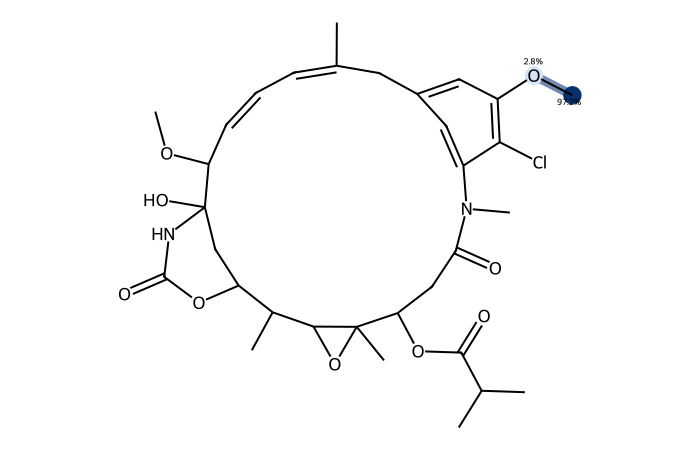

In [14]:
SMILES = 'COc1cc2cc(c1Cl)N(C)C(=O)CC(OC(=O)C(C)C)C1(C)OC1C(C)C1CC(O)(NC(=O)O1)C(OC)C=CC=C(C)C2'
## N#CC1=C(N)N(c2ccccc2)C(c2ccccc2)C1(C#N)C#N
img = full_analysis(SMILES, interpreter, top_k_atoms=5)

## 8 · Batch analysis

───────────────────────────────────────────────────────
  Benzene  (c1ccccc1)
  Prediction  : Inactive  (conf: 82.3%)
  Active atoms: 10


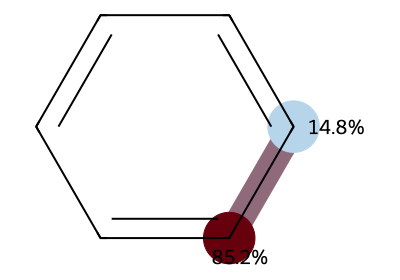

───────────────────────────────────────────────────────
  Naphthalene  (c1ccc2ccccc2c1)
  Prediction  : Inactive  (conf: 86.3%)
  Active atoms: 10


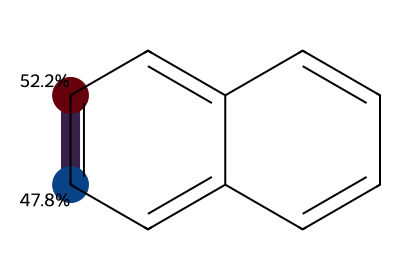

───────────────────────────────────────────────────────
  Phenol  (Oc1ccccc1)
  Prediction  : Inactive  (conf: 79.3%)
  Active atoms: 10


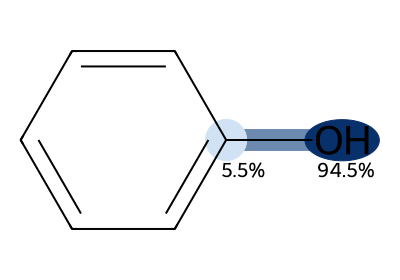

───────────────────────────────────────────────────────
  Aniline  (Nc1ccccc1)
  Prediction  : Inactive  (conf: 76.5%)
  Active atoms: 10


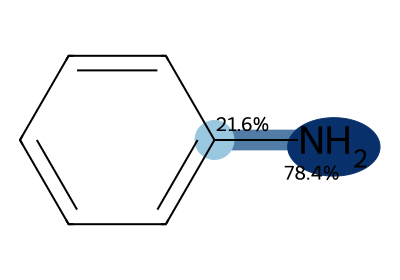

───────────────────────────────────────────────────────
  Aspirin  (CC(=O)Oc1ccccc1C(=O)O)
  Prediction  : Inactive  (conf: 86.7%)
  Active atoms: 10


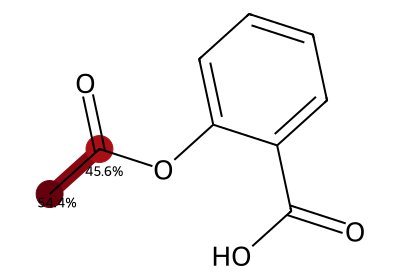

───────────────────────────────────────────────────────
  Caffeine  (Cn1cnc2c1c(=O)n(C)c(=O)n2C)
  Prediction  : Inactive  (conf: 71.1%)
  Active atoms: 10


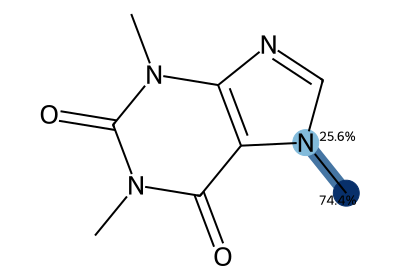


═══════════════════════════════════════════════════════
  Compound         Prediction           Conf  Atoms
  ────────────────────────────────────────────────────
  Benzene          Inactive            82.3%     10
  Naphthalene      Inactive            86.3%     10
  Phenol           Inactive            79.3%     10
  Aniline          Inactive            76.5%     10
  Aspirin          Inactive            86.7%     10
  Caffeine         Inactive            71.1%     10


In [15]:
COMPOUNDS = {
    'Benzene'    : 'c1ccccc1',
    'Naphthalene': 'c1ccc2ccccc2c1',
    'Phenol'     : 'Oc1ccccc1',
    'Aniline'    : 'Nc1ccccc1',
    'Aspirin'    : 'CC(=O)Oc1ccccc1C(=O)O',
    'Caffeine'   : 'Cn1cnc2c1c(=O)n(C)c(=O)n2C',
}

summary = []

for name, smi in COMPOUNDS.items():
    _, graph = smiles_to_mol_and_graph(smi)
    exp      = interpreter.explain_prediction(graph, top_k_atoms=5)
    conf_str = (
        f"{exp['confidence']*100:.1f}%"
        if exp['confidence'] is not None else 'N/A'
    )
    summary.append(dict(
        Compound=name, Prediction=exp['prediction_label'],
        Confidence=conf_str, ActiveAtoms=exp['n_active_atoms'],
    ))
    print(f"{'─'*55}")
    print(f"  {name}  ({smi})")
    print(f"  Prediction  : {exp['prediction_label']}  (conf: {conf_str})")
    print(f"  Active atoms: {exp['n_active_atoms']}")
    display(visualise_prediction(smi, interpreter, top_k_atoms=5, img_size=(400, 280)))

print(f"\n{'═'*55}")
print(f"  {'Compound':<16} {'Prediction':<18} {'Conf':>6}  {'Atoms':>5}")
print(f"  {'─'*52}")
for r in summary:
    print(f"  {r['Compound']:<16} {r['Prediction']:<18}"
          f" {r['Confidence']:>6}  {r['ActiveAtoms']:>5}")